# Formative 2 – PCA
## Part 2: Choosing the number of components and making PCA faster

This notebook continues from `PCA_Formative2_Person1.ipynb`. Part 1 cleaned the Rwanda Seasonal Agricultural
Survey (2024 Season B) data and did PCA by hand. Here we do:

* **Task 2** – pick the number of principal components from the explained variance
* **Task 3** – make the PCA code faster and test it on bigger data

We only use `numpy` and `matplotlib`. The file is read with Python's built-in `csv` module.

In [22]:
import csv
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the clean data from Part 1
`data/processed/sas_2024B_pca_ready.csv` has no missing values and every column is already a number.

In [23]:
with open("data/processed/sas_2024B_pca_ready.csv") as f:
    reader = csv.reader(f)
    feature_names = next(reader)
    X = np.array([[float(v) for v in row] for row in reader])

print("Shape:", X.shape)
print("Missing values:", np.isnan(X).sum())
print("Features:", feature_names)

Shape: (17260, 20)
Missing values: 0
Features: ['age', 'area', 'labour_cost', 'erosion_cost', 'irrigation_cost', 'erosion_level', 'anti_erosion', 'consolidated', 'machine', 'irrigated', 'gender_Female', 'gender_Organisation', 'province_East', 'province_North', 'province_South', 'province_West', 'stratum_large farm', 'stratum_marshland', 'stratum_mixed', 'stratum_rangeland']


## 2. Scale and run PCA (same steps as Part 1)
We z-score every column so that no feature wins just because of its units, then get the sorted eigenvalues
and eigenvectors of the covariance matrix.

In [24]:
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

X_centered = X_scaled - X_scaled.mean(axis=0)
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues (largest first):", eigenvalues.round(3))

Eigenvalues (largest first): [3.752 1.728 1.33  1.255 1.13  1.09  1.055 1.023 1.003 0.916 0.892 0.848
 0.842 0.784 0.764 0.668 0.339 0.284 0.232 0.065]


---
# Task 2: How many principal components?
### Step 1: Explained variance
Each eigenvalue is the variance along its principal component. Dividing it by the sum of all eigenvalues gives the
share of the total variance that the component explains. The cumulative sum tells us how much we keep if we use
the first k components.

In [25]:
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

print(f"{'PC':<6}{'eigenvalue':>11}{'explained':>11}{'cumulative':>12}")
for i in range(len(eigenvalues)):
    print(f"PC{i+1:<4}{eigenvalues[i]:>11.3f}{explained[i]*100:>10.1f}%{cumulative[i]*100:>11.1f}%")

PC     eigenvalue  explained  cumulative
PC1         3.752      18.8%       18.8%
PC2         1.728       8.6%       27.4%
PC3         1.330       6.6%       34.0%
PC4         1.255       6.3%       40.3%
PC5         1.130       5.7%       46.0%
PC6         1.090       5.4%       51.4%
PC7         1.055       5.3%       56.7%
PC8         1.023       5.1%       61.8%
PC9         1.003       5.0%       66.8%
PC10        0.916       4.6%       71.4%
PC11        0.892       4.5%       75.9%
PC12        0.848       4.2%       80.1%
PC13        0.842       4.2%       84.3%
PC14        0.784       3.9%       88.2%
PC15        0.764       3.8%       92.1%
PC16        0.668       3.3%       95.4%
PC17        0.339       1.7%       97.1%
PC18        0.284       1.4%       98.5%
PC19        0.232       1.2%       99.7%
PC20        0.065       0.3%      100.0%


### Step 2: Scree plot and cumulative explained variance
The bars show how much each component explains on its own. The line shows the running total.

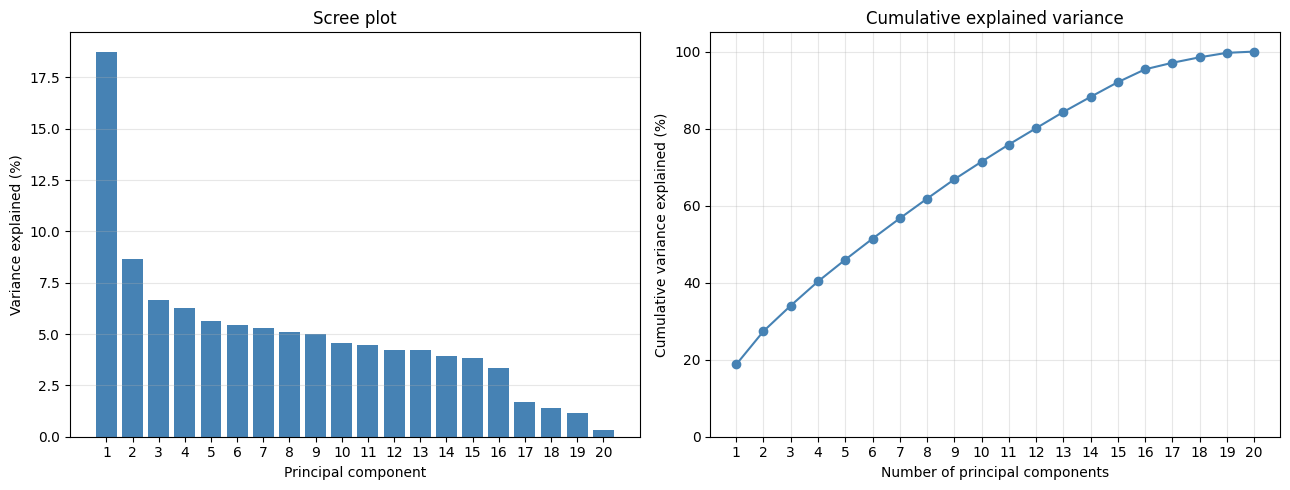

In [26]:
pcs = np.arange(1, len(eigenvalues) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(pcs, explained * 100, color="steelblue")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained (%)")
ax1.set_title("Scree plot")
ax1.set_xticks(pcs)
ax1.grid(alpha=0.3, axis="y")

ax2.plot(pcs, cumulative * 100, marker="o", color="steelblue")
ax2.set_xlabel("Number of principal components")
ax2.set_ylabel("Cumulative variance explained (%)")
ax2.set_title("Cumulative explained variance")
ax2.set_xticks(pcs)
ax2.set_ylim(0, 105)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/explained_variance.png")
plt.show()

### Step 3: Pick k dynamically
Instead of fixing k by hand, we give a target share of variance to keep and let the code find the smallest k
that reaches it. If the data changes, k changes with it.

In [27]:
def choose_k(eigenvalues, threshold):
    """Smallest number of components whose cumulative explained variance reaches the threshold."""
    cumulative = np.cumsum(eigenvalues) / eigenvalues.sum()
    return int(np.argmax(cumulative >= threshold)) + 1

for t in [0.80, 0.90, 0.95]:
    k_t = choose_k(eigenvalues, t)
    print(f"Keep {t*100:.0f}% of variance -> k = {k_t:<3} ({cumulative[k_t-1]*100:.1f}% kept, "
          f"{len(eigenvalues) - k_t} of {len(eigenvalues)} dimensions dropped)")

Keep 80% of variance -> k = 12  (80.1% kept, 8 of 20 dimensions dropped)
Keep 90% of variance -> k = 15  (92.1% kept, 5 of 20 dimensions dropped)
Keep 95% of variance -> k = 16  (95.4% kept, 4 of 20 dimensions dropped)


In [28]:
threshold = 0.90   # the share of variance we want to keep
k = choose_k(eigenvalues, threshold)

print("Chosen threshold:", threshold)
print("Chosen k:", k)
print(f"Variance kept: {cumulative[k-1]*100:.1f}%   Variance lost: {(1 - cumulative[k-1])*100:.1f}%")

Chosen threshold: 0.9
Chosen k: 15
Variance kept: 92.1%   Variance lost: 7.9%


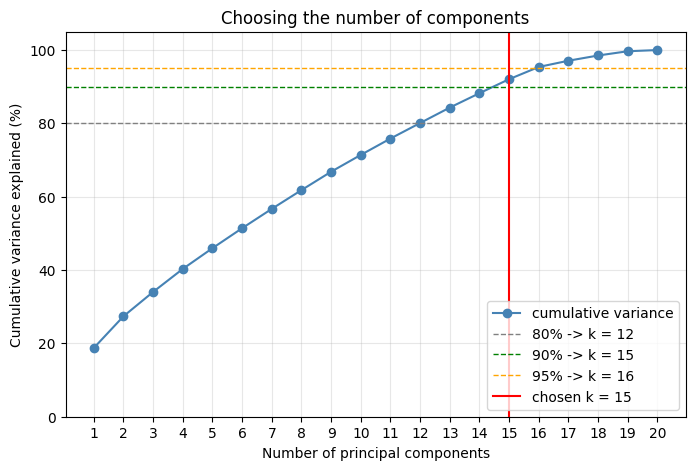

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(pcs, cumulative * 100, marker="o", color="steelblue", label="cumulative variance")

for t, c in [(0.80, "gray"), (0.90, "green"), (0.95, "orange")]:
    plt.axhline(t * 100, color=c, linestyle="--", linewidth=1, label=f"{t*100:.0f}% -> k = {choose_k(eigenvalues, t)}")

plt.axvline(k, color="red", linewidth=1.5, label=f"chosen k = {k}")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative variance explained (%)")
plt.title("Choosing the number of components")
plt.xticks(pcs)
plt.ylim(0, 105)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("figures/choosing_k.png")
plt.show()

### Step 4: Project the data onto the k components

In [30]:
W = eigenvectors[:, :k]
X_pca = X_centered @ W

print("Before:", X_centered.shape)
print("After: ", X_pca.shape)
print("Variance of each new column matches its eigenvalue:",
      np.allclose(X_pca.var(axis=0, ddof=1), eigenvalues[:k]))

Before: (17260, 20)
After:  (17260, 15)
Variance of each new column matches its eigenvalue: True


### Step 5: What information is lost?
We rebuild the data from the k components (`X_pca @ W.T`) and compare it with the original. For each feature, the
share of its variance that we cannot rebuild is the information the dropped components carried about that feature.

In [31]:
X_rebuilt = X_pca @ W.T
error = X_centered - X_rebuilt

lost_total = (error ** 2).sum() / (X_centered ** 2).sum()
print(f"Total variance lost: {lost_total*100:.1f}%  (same as 1 - cumulative[k-1] = {(1 - cumulative[k-1])*100:.1f}%)")

lost_per_feature = error.var(axis=0) / X_centered.var(axis=0)
order_lost = np.argsort(lost_per_feature)[::-1]

print("\nShare of each feature's variance lost (largest first):")
for j in order_lost:
    print(f"  {feature_names[j]:<22} {lost_per_feature[j]*100:5.1f}%")

Total variance lost: 7.9%  (same as 1 - cumulative[k-1] = 7.9%)

Share of each feature's variance lost (largest first):
  consolidated            37.2%
  stratum_large farm      22.9%
  gender_Organisation     22.7%
  area                    21.2%
  irrigated               15.5%
  irrigation_cost         14.4%
  machine                  5.6%
  province_East            4.7%
  province_West            2.9%
  stratum_rangeland        1.9%
  province_South           1.8%
  province_North           1.5%
  age                      1.4%
  stratum_marshland        1.3%
  gender_Female            1.2%
  labour_cost              1.1%
  erosion_cost             0.9%
  anti_erosion             0.3%
  stratum_mixed            0.3%
  erosion_level            0.0%


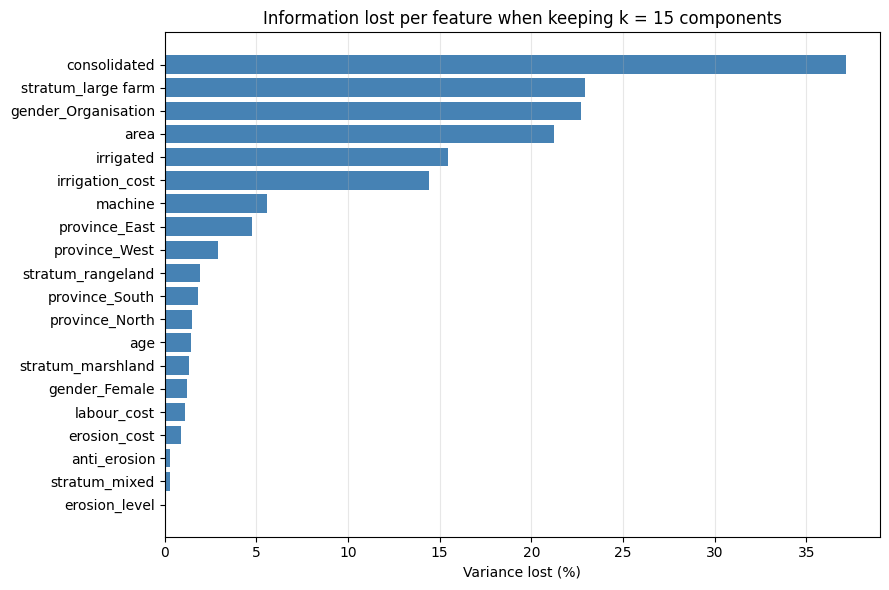

In [32]:
plt.figure(figsize=(9, 6))
plt.barh([feature_names[j] for j in order_lost][::-1], lost_per_feature[order_lost][::-1] * 100, color="steelblue")
plt.xlabel("Variance lost (%)")
plt.title(f"Information lost per feature when keeping k = {k} components")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("figures/information_lost.png")
plt.show()

In [33]:
dropped = eigenvectors[:, k:]

print(f"Features with the biggest weights in the dropped components (PC{k+1} to PC{len(eigenvalues)}):")
for i in range(dropped.shape[1]):
    top = np.argsort(np.abs(dropped[:, i]))[::-1][:3]
    names = ", ".join(f"{feature_names[j]} ({dropped[j, i]:+.2f})" for j in top)
    print(f"  PC{k+i+1:<3} ({explained[k+i]*100:.1f}%): {names}")

Features with the biggest weights in the dropped components (PC16 to PC20):
  PC16  (3.3%): consolidated (-0.73), gender_Organisation (+0.33), stratum_large farm (+0.32)
  PC17  (1.7%): area (-0.58), irrigated (+0.49), gender_Organisation (+0.41)
  PC18  (1.4%): stratum_large farm (-0.67), gender_Organisation (+0.58), irrigation_cost (+0.29)
  PC19  (1.2%): area (+0.64), irrigation_cost (-0.52), irrigated (+0.40)
  PC20  (0.3%): province_East (-0.54), province_South (-0.52), province_West (-0.49)


Why this number of components?

We chose a threshold of 0.90, which gives k = 15 and keeps 92.1% of the variance. The scree plot has two clear breaks. The first is after PC1, which explains 18.8% while PC2 explains only 8.6%. The second is between PC16 and PC17, where the eigenvalue falls from 0.668 to 0.339. Between these two breaks the bars go down slowly and evenly, so there is no early elbow that would let us keep only a few components. Because of that, we used a variance target instead of an elbow. At 0.90, k = 15 is the first number of components that reaches the target. The second break shows that k = 16 would also be reasonable. We stayed at 15 because it was already more than 90%. The price is that we drop PC16, where consolidated has its biggest weight (−0.73), so PC16 carries most of the parts of consolidated that we lose.

The tradeoff

The gain is that the data goes from 20 dimensions to 15, which is 25% fewer columns. The cost is that 7.9% of the variance is lost. This is a modest reduction, and the eigenvalues explain why. We standardized every feature, so the eigenvalues add up to 20 and their average is exactly 1. Most of our eigenvalues are close to 1, so each component explains about as much as one original feature. This means the features are only weakly correlated: each one mostly carries its own information, so PCA does not have much overlap to combine. If the features were strongly correlated, the first few eigenvalues would be much bigger than 1 and a few components would be enough. Here that happens mainly with PC1 (3.75), and to a smaller extent PC2 (1.73). The very small components do show real redundancy. PC20 (0.065) is made of the province columns, which partly depend on each other because they come from one-hot encoding.

What information is lost?

The lost 7.9% is not spread evenly across the features. The ones that lose the most are consolidated (37.2%), stratum_large farm (22.9%), gender_Organisation (22.7%), area (21.2%), irrigated (15.5%) and irrigation_cost (14.4%). These features have big weights in the dropped components PC16 to PC19. This is not because they are rare. Every standardized feature has variance 1 and adds the same amount to the total, whether it is rare or common. They lose more because part of their variation is not shared with the main patterns in the data, so it ends up in the small components that we drop. For real farm plots, this means the reduced data describes land consolidation plots, large farms, organisation-run plots and irrigated plots less accurately, and it gives plot size less precisely. The information is not gone completely, because 63% of consolidated is still kept. The dropped components PC16 to PC19 have small eigenvalues, but what they carry matters for policy, such as irrigation investment or the consolidation programme. So a component with low variance is not necessarily a component with low importance. On the other side, some features are kept almost perfectly: erosion_level (0.0% lost), anti_erosion (0.3%), erosion_cost (0.9%), labour_cost (1.1%), farmer age (1.4%), female holder (1.2%) and the provinces (1.5% to 4.7%). So the 15 components still describe typical smallholder plots well, but a study focused on consolidation or irrigation should use the original features or keep more components.


---
# Task 3: Making PCA faster and able to handle large data
### Step 1: The original version
These are the same steps as Part 1 in one function: scale, center, covariance, eigen decomposition, sort, project.
Every step makes a new full-size copy of the data (`X - mean`, `/ std`, `- mean` again), so for n rows it
holds several n × 20 arrays in memory at the same time.

In [34]:
def pca_original(X, k):
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    X_centered = X_scaled - X_scaled.mean(axis=0)
    cov_matrix = (X_centered.T @ X_centered) / (X.shape[0] - 1)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    return X_centered @ eigenvectors[:, :k], eigenvalues

### Step 2: The optimized version
Changes:

1. **Read the data in chunks, once.** For each chunk we only add up the column sums and `chunk.T @ chunk`
   (a 20 × 20 matrix). From these totals we get the mean, the standard deviation and the covariance, without ever
   making a scaled or centered copy of the whole dataset. Memory for this part stays the same no matter how many
   rows there are.
2. **Scale inside the eigenvectors instead of the data.** Scaling and centering is
   `(X - mean) / std @ W`, which equals `X @ (W / std) - (mean / std) @ W`. So we change the small 20 × k matrix
   once, and project each chunk directly.
3. **No `argsort`.** `np.linalg.eigh` already returns eigenvalues from smallest to largest, so we just reverse
   them.
4. **Only keep k eigenvectors** and write the projected chunks straight into one output array.

In [35]:
def pca_optimized(X, k, chunk_size=50_000):
    n, d = X.shape

    # One pass over the data: column sums and X.T @ X, chunk by chunk
    col_sum = np.zeros(d)
    xtx = np.zeros((d, d))
    for start in range(0, n, chunk_size):
        chunk = X[start:start + chunk_size]
        col_sum += chunk.sum(axis=0)
        xtx += chunk.T @ chunk

    mean = col_sum / n
    cov_raw = (xtx - n * np.outer(mean, mean)) / (n - 1)
    std = np.sqrt(np.diag(cov_raw) * (n - 1) / n)     # same as X.std(axis=0)
    cov_matrix = cov_raw / np.outer(std, std)         # covariance of the scaled data

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    eigenvalues = eigenvalues[::-1]
    W = eigenvectors[:, ::-1][:, :k]

    # Put the scaling into W, then project chunk by chunk
    W_scaled = W / std[:, None]
    shift = (mean / std) @ W
    X_pca = np.empty((n, k))
    for start in range(0, n, chunk_size):
        X_pca[start:start + chunk_size] = X[start:start + chunk_size] @ W_scaled - shift
    return X_pca, eigenvalues

### Step 3: Check that both give the same answer

In [36]:
pca_a, eig_a = pca_original(X, k)
pca_b, eig_b = pca_optimized(X, k)

print("Same eigenvalues:", np.allclose(eig_a, eig_b))
print("Same projected data:", np.allclose(pca_a, pca_b))
print("Largest difference:", np.abs(pca_a - pca_b).max())
print("Same as Task 2 result:", np.allclose(pca_b, X_pca))

Same eigenvalues: True
Same projected data: True
Largest difference: 2.1596058275008545e-11
Same as Task 2 result: True


### Step 4: Benchmark on bigger data
Our survey has 17,260 rows. To test bigger sizes we build larger datasets by picking rows from it at random
(with repeats), up to 3 million rows.

For each size we measure:
* **time** – best of 3 runs, with `time.perf_counter`
* **peak memory** – the most memory used during the run, with `tracemalloc` (both are in Python's standard library)

In [37]:
import time
import tracemalloc

def measure(pca_function, data, k, repeats=3):
    best_time = float("inf")
    for _ in range(repeats):
        start = time.perf_counter()
        pca_function(data, k)
        best_time = min(best_time, time.perf_counter() - start)

    tracemalloc.start()
    pca_function(data, k)
    peak_memory = tracemalloc.get_traced_memory()[1]
    tracemalloc.stop()
    return best_time, peak_memory / 1e6   # seconds, MB

In [38]:
rng = np.random.default_rng(42)
sizes = [17_260, 200_000, 1_000_000, 3_000_000]
results = []

print(f"{'rows':>10} {'data MB':>8} | {'original s':>10} {'MB':>7} | {'optimized s':>11} {'MB':>7} | {'faster':>6} {'less memory':>11}")
for size in sizes:
    X_big = X if size == len(X) else X[rng.integers(0, len(X), size)]
    t_orig, m_orig = measure(pca_original, X_big, k)
    t_opt, m_opt = measure(pca_optimized, X_big, k)
    results.append((size, t_orig, m_orig, t_opt, m_opt))
    print(f"{size:>10,} {X_big.nbytes/1e6:>8.0f} | {t_orig:>10.3f} {m_orig:>7.0f} | {t_opt:>11.3f} {m_opt:>7.0f} | "
          f"{t_orig/t_opt:>5.1f}x {m_orig/m_opt:>10.1f}x")

results = np.array(results)
del X_big

      rows  data MB | original s      MB | optimized s      MB | faster less memory
    17,260        3 |      0.002       8 |       0.001       6 |   2.1x        1.2x
   200,000       32 |      0.024      88 |       0.009      36 |   2.8x        2.4x
 1,000,000      160 |      0.131     440 |       0.042     132 |   3.1x        3.3x
 3,000,000      480 |      0.359    1320 |       0.126     372 |   2.9x        3.5x


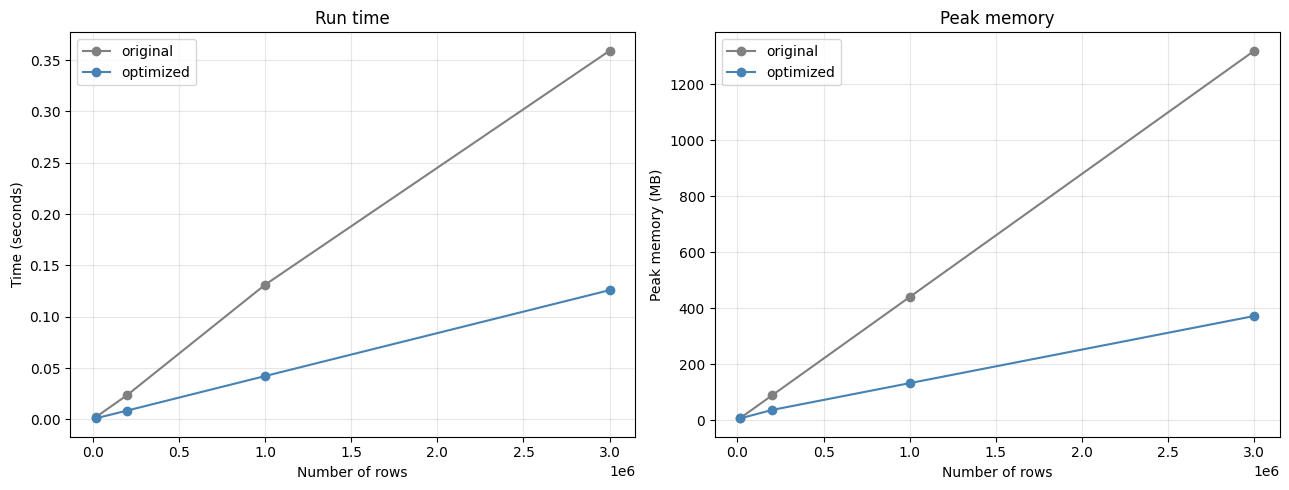

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(results[:, 0], results[:, 1], marker="o", color="gray", label="original")
ax1.plot(results[:, 0], results[:, 3], marker="o", color="steelblue", label="optimized")
ax1.set_xlabel("Number of rows")
ax1.set_ylabel("Time (seconds)")
ax1.set_title("Run time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(results[:, 0], results[:, 2], marker="o", color="gray", label="original")
ax2.plot(results[:, 0], results[:, 4], marker="o", color="steelblue", label="optimized")
ax2.set_xlabel("Number of rows")
ax2.set_ylabel("Peak memory (MB)")
ax2.set_title("Peak memory")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/benchmark.png")
plt.show()

### Step 5: Data that does not fit in memory
A national survey over many seasons, or data from every farm plot in the country, could be too big to load at once.
`pca_original` needs the whole array (plus copies) in memory, so it cannot run at all in that case.

The optimized version only ever looks at one chunk at a time, so it also works when the chunks come straight from
a file or a database. Here we simulate that with **50 million rows** (8 GB if it were one array). The chunks are
made on the fly from our survey rows and thrown away after use, so the full dataset never exists in memory.

In [40]:
total_rows = 50_000_000
chunk_size = 500_000

def make_chunks():
    """Give the big dataset one chunk at a time. Same seed, so every pass sees the same rows."""
    chunk_rng = np.random.default_rng(7)
    for start in range(0, total_rows, chunk_size):
        yield X[chunk_rng.integers(0, len(X), min(chunk_size, total_rows - start))]

print(f"Rows: {total_rows:,}   Chunk size: {chunk_size:,}   Chunks: {total_rows // chunk_size}")
print(f"Size if loaded as one array: {total_rows * X.shape[1] * 8 / 1e9:.1f} GB")
print(f"Size of one chunk: {chunk_size * X.shape[1] * 8 / 1e6:.0f} MB")

Rows: 50,000,000   Chunk size: 500,000   Chunks: 100
Size if loaded as one array: 8.0 GB
Size of one chunk: 80 MB


In [41]:
def pca_streaming_fit(get_chunks, k):
    """Same maths as pca_optimized, but the data comes from a function that yields chunks."""
    n = 0
    col_sum = None
    for chunk in get_chunks():
        if col_sum is None:
            col_sum = np.zeros(chunk.shape[1])
            xtx = np.zeros((chunk.shape[1], chunk.shape[1]))
        n += len(chunk)
        col_sum += chunk.sum(axis=0)
        xtx += chunk.T @ chunk

    mean = col_sum / n
    cov_raw = (xtx - n * np.outer(mean, mean)) / (n - 1)
    std = np.sqrt(np.diag(cov_raw) * (n - 1) / n)
    cov_matrix = cov_raw / np.outer(std, std)

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    eigenvalues = eigenvalues[::-1]
    W = eigenvectors[:, ::-1][:, :k]
    return eigenvalues, W / std[:, None], (mean / std) @ W   # eigenvalues, W_scaled, shift

tracemalloc.start()
start = time.perf_counter()
big_eigenvalues, W_scaled, shift = pca_streaming_fit(make_chunks, k)
fit_time = time.perf_counter() - start
peak = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

print(f"Time: {fit_time:.1f} s   Peak memory: {peak / 1e6:.0f} MB")
print("Eigenvalues (50M rows):     ", big_eigenvalues.round(3))
print("Eigenvalues (survey, 17k):  ", eigenvalues.round(3))

Time: 3.5 s   Peak memory: 164 MB
Eigenvalues (50M rows):      [3.753 1.728 1.329 1.255 1.13  1.089 1.055 1.023 1.003 0.916 0.892 0.848
 0.842 0.785 0.764 0.668 0.339 0.285 0.232 0.065]
Eigenvalues (survey, 17k):   [3.752 1.728 1.33  1.255 1.13  1.09  1.055 1.023 1.003 0.916 0.892 0.848
 0.842 0.784 0.764 0.668 0.339 0.284 0.232 0.065]


The eigenvalues are almost the same as for the real survey, which makes sense because the big dataset is made
from the same rows. Peak memory depends on the chunk size (a couple of chunks at a time), not on the size of the data.

Now we project the data. The result (50M × k) would also be too big to keep, so we handle each projected chunk as
it comes; here we just add up its squares to check that the variance of each component equals its eigenvalue.

In [42]:
tracemalloc.start()
start = time.perf_counter()

n = 0
pc_sum = np.zeros(k)
pc_sum_sq = np.zeros(k)
for chunk in make_chunks():
    projected = chunk @ W_scaled - shift       # this is where the chunk would be saved or used
    n += len(projected)
    pc_sum += projected.sum(axis=0)
    pc_sum_sq += (projected ** 2).sum(axis=0)

project_time = time.perf_counter() - start
peak = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

pc_variance = (pc_sum_sq - pc_sum ** 2 / n) / (n - 1)
print(f"Rows projected: {n:,}   Time: {project_time:.1f} s   Peak memory: {peak / 1e6:.0f} MB")
print("Variance of each PC matches its eigenvalue:", np.allclose(pc_variance, big_eigenvalues[:k]))

Rows projected: 50,000,000   Time: 4.4 s   Peak memory: 260 MB
Variance of each PC matches its eigenvalue: True


What made the optimized version faster?

The original version goes over the full dataset several times and makes a new full-size array at each step. It subtracts the mean, divides by the standard deviation, and then subtracts the mean again. That last step does nothing, because standardized data already has mean 0. Then it builds the covariance from the centered copy and projects that copy. The optimized version makes only two passes over the data, both in chunks, and never makes a full-size copy. In the first pass it only adds up the column sums and chunk.T @ chunk, which is a small 20 × 20 matrix. From these totals we get the mean, the standard deviation and the covariance directly, so we never build a scaled or centered copy of the data. In the second pass it projects each chunk. The scaling is moved into the eigenvector matrix, which is only 20 × k, instead of being applied to millions of rows. Removing argsort and keeping only k eigenvectors are small changes. They only touch a 20 × 20 matrix, so they barely affect the time. The main gain is doing less work on the big array. On our real survey (17,260 rows) both versions take about 0.002 s, so there is no difference. From 200,000 rows upward the optimized version is about 3× faster, for example 0.129 s instead of 0.383 s at 3 million rows. Both versions give the same result: the largest difference in the projected data is about 2 × 10⁻¹¹.

Why does it use less memory?

The original keeps several full-size arrays in memory at the same time. At 3 million rows the data itself is 480 MB. The temporary "data minus mean" array is freed once the scaled data is made. After that, the scaled data (480 MB), the centered data (480 MB) and the output (360 MB) all exist together, which gives exactly the 1,320 MB peak. That is about 2.75 times the data size. The optimized version peaks at 372 MB. Most of that is the output array (3 million × 15 values). The fitting step only needs the 20 × 20 totals and one chunk at a time. So memory for fitting depends on the chunk size, not on the number of rows. Across our tests the saving grows from 1.2× on the survey to 3.5× at 3 million rows.

What can it do that the original can't?

The original needs the whole dataset loaded as one array, plus its copies. If the data is bigger than the computer's memory, it cannot run at all. Using our own ratio of about 2.75 times the data size, 8 GB of data would need about 22 GB of memory. The optimized version only looks at one chunk at a time, so the chunks can come from a file or a database. That is what a national survey over many seasons would need. We tested this with 50 million rows, which would be 8 GB as one array. The rows were resampled from our survey and generated chunk by chunk, so the full dataset never existed in memory. We processed it in chunks of 500,000 rows (80 MB each). Fitting took 3.3 s with a peak memory of 164 MB, and projecting all 50 million rows took 4.5 s with a peak of 260 MB. The variance of each projected component matched its eigenvalue, which shows the chunked projection is correct. The eigenvalues were almost the same as on the real survey. That is expected, because the 50 million rows are the same survey rows repeated, so it confirms the method rather than showing new results. This test shows that the streaming version runs on data far too large for the original version, with memory that stays small.
